# Smart MCQ Solver — Full Pipeline
Four models + ensemble, targeting MAP@3 ≥ 0.8:

1. **From scratch**: TF-IDF + Logistic Regression
2. **Pretrained #1**: Sentence-embedding cosine similarity (zero-shot, no fine-tuning)
3. **Pretrained #2 / additional**: NLI entailment scoring (zero-shot, no fine-tuning)
4. **Fine-tuned**: DeBERTa-v3 fine-tuned as a proper multiple-choice classifier

Then a weighted-score ensemble tuned on a validation split.

**Before running:** update the `CONFIG` cell below with your actual file paths and column names.


In [21]:
!pip install -q sentence-transformers transformers accelerate torch scikit-learn pandas numpy tqdm matplotlib

In [22]:
import os, re, json, random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## Config — edit these to match your dataset

In [23]:
# ==== CONFIG: update these paths / column names to match your data ====
TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH  = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SAMPLE_SUB_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

ID_COL = "id"
QUESTION_COL = "question"
OPTION_COLS = {"A": "A", "B": "B", "C": "C", "D": "D", "E": "E"}
ANSWER_COL = "answer"   # column in train.csv holding the correct letter (A-E)

OUTPUT_SUB_PATH = "submission.csv"
LABELS = ["A", "B", "C", "D", "E"]

## Load data

In [24]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(train_df.shape, test_df.shape)
train_df.head()

(2000, 8) (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## EDA
Label balance, option-length leakage, question length, missing values, duplicates.

Answer label distribution:
answer
B    0.2450
C    0.2295
A    0.1845
D    0.1790
E    0.1620
Name: proportion, dtype: float64


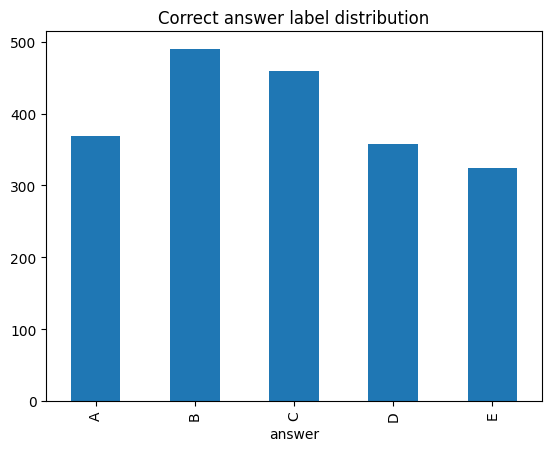

In [25]:
print("Answer label distribution:")
print(train_df[ANSWER_COL].value_counts(normalize=True))

import matplotlib.pyplot as plt
train_df[ANSWER_COL].value_counts().reindex(LABELS).plot(kind="bar", title="Correct answer label distribution")
plt.show()

In [26]:
# Check whether the correct option is systematically longer/shorter than distractors
def option_lengths(row):
    return {l: len(str(row[OPTION_COLS[l]])) for l in LABELS}

len_df = train_df.apply(option_lengths, axis=1, result_type="expand")
train_df_lens = pd.concat([train_df[[ANSWER_COL]], len_df], axis=1)

correct_lens, incorrect_lens = [], []
for _, row in train_df_lens.iterrows():
    ans = row[ANSWER_COL]
    for l in LABELS:
        (correct_lens if l == ans else incorrect_lens).append(row[l])

print("Mean length of correct option:", np.mean(correct_lens))
print("Mean length of incorrect option:", np.mean(incorrect_lens))

Mean length of correct option: 181.879
Mean length of incorrect option: 160.712375


In [27]:
QUESTION_COL = "prompt"        # or "Question", "text", "context"
OPTION_COLS = {"A": "A", "B": "B", "C": "C", "D": "D", "E": "E"}
                                # or {"A": "option_a", "B": "option_b", ...}
ANSWER_COL = "answer"          # or "label", "correct", "Answer"
ID_COL = "id"                  # or "ID", "Id"
train_df["question_len"] = train_df[QUESTION_COL].astype(str).apply(len)
print(train_df["question_len"].describe())

print("\nMissing values:\n", train_df.isnull().sum())
print("\nDuplicate questions:", train_df[QUESTION_COL].duplicated().sum())

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: question_len, dtype: float64

Missing values:
 id              0
prompt          0
A               0
B               0
C               0
D               0
E               0
answer          0
question_len    0
dtype: int64

Duplicate questions: 242


## Validation split + MAP@3 metric
Used to score every model offline before touching submissions.

In [28]:
def map_at_3(true_labels, pred_lists):
    scores = []
    for true, preds in zip(true_labels, pred_lists):
        score = 0.0
        for i, p in enumerate(preds[:3]):
            if p == true:
                score = 1.0 / (i + 1)
                break
        scores.append(score)
    return np.mean(scores)

def normalize_per_question(df, id_col=ID_COL, score_col="score"):
    df = df.copy()
    df[score_col] = df.groupby(id_col)[score_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
    )
    return df

train_data, val_data = train_test_split(
    train_df, test_size=0.15, stratify=train_df[ANSWER_COL], random_state=SEED
)
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
print(train_data.shape, val_data.shape)

(1700, 9) (300, 9)


## Model 1 — From scratch: TF-IDF + Logistic Regression
No pretrained weights anywhere in this model. Treats each (question, option) pair as a binary
"is this the correct option?" classification, then ranks options by predicted probability.

In [29]:
def build_option_text(row):
    q = str(row[QUESTION_COL])
    return {l: q + " [SEP] " + str(row[OPTION_COLS[l]]) for l in LABELS}

def expand_to_option_rows(df, is_train=True):
    rows = []
    for _, row in df.iterrows():
        opt_texts = build_option_text(row)
        for l in LABELS:
            rows.append({
                ID_COL: row[ID_COL],
                "label": l,
                "text": opt_texts[l],
                "is_correct": int(row[ANSWER_COL] == l) if is_train else None
            })
    return pd.DataFrame(rows)

train_expanded = expand_to_option_rows(train_data, is_train=True)
val_expanded = expand_to_option_rows(val_data, is_train=True)
test_expanded = expand_to_option_rows(test_df, is_train=False)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_expanded["text"])
X_val_tfidf = tfidf.transform(val_expanded["text"])
X_test_tfidf = tfidf.transform(test_expanded["text"])

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_tfidf, train_expanded["is_correct"])

val_scores_tfidf_df = normalize_per_question(pd.DataFrame({
    ID_COL: val_expanded[ID_COL],
    "label": val_expanded["label"],
    "score": clf.predict_proba(X_val_tfidf)[:, 1]
}))
test_scores_tfidf_df = normalize_per_question(pd.DataFrame({
    ID_COL: test_expanded[ID_COL],
    "label": test_expanded["label"],
    "score": clf.predict_proba(X_test_tfidf)[:, 1]
}))

val_rank_tfidf = {qid: g.sort_values("score", ascending=False)["label"].tolist()
                  for qid, g in val_scores_tfidf_df.groupby(ID_COL)}
truth = val_data.set_index(ID_COL)[ANSWER_COL]
print("TF-IDF + LogReg val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_tfidf.keys())).tolist(), list(val_rank_tfidf.values())))

TF-IDF + LogReg val MAP@3: 0.98


## Model 2 — Pretrained: sentence-embedding cosine similarity
Zero-shot, no fine-tuning. Embeds the question and each option and ranks by cosine similarity.
Complementary to TF-IDF because it captures semantic (not just lexical) closeness.

In [30]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)

def embed_texts(texts, batch_size=64):
    return embed_model.encode(texts, batch_size=batch_size, show_progress_bar=True, normalize_embeddings=True)

def compute_embedding_scores(df):
    q_embs = embed_texts(df[QUESTION_COL].astype(str).tolist())
    records = []
    for l in LABELS:
        opt_embs = embed_texts(df[OPTION_COLS[l]].astype(str).tolist())
        sims = np.sum(q_embs * opt_embs, axis=1)  # cosine, since embeddings are normalized
        for qid, sim in zip(df[ID_COL], sims):
            records.append({ID_COL: qid, "label": l, "score": sim})
    return pd.DataFrame(records)

val_scores_embed = normalize_per_question(compute_embedding_scores(val_data))
test_scores_embed = normalize_per_question(compute_embedding_scores(test_df))

val_rank_embed = {qid: g.sort_values("score", ascending=False)["label"].tolist()
                  for qid, g in val_scores_embed.groupby(ID_COL)}
print("Embedding similarity val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_embed.keys())).tolist(), list(val_rank_embed.values())))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding similarity val MAP@3: 0.45388888888888895


## Model 3 — Additional model: zero-shot NLI entailment scoring
Treats the question as a premise and each option as a hypothesis; scores by entailment probability.
This captures logical fit rather than lexical/semantic closeness, which is good diversity for the ensemble.

In [31]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GEMINI_API_KEY")
secret_value_1 = user_secrets.get_secret("hf token")
secret_value_2 = user_secrets.get_secret("HF_TOKEN")
secret_value_3 = user_secrets.get_secret("trackio")
secret_value_4 = user_secrets.get_secret("TRACKIO_KEY")

In [32]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")   # or "hf token" — use the exact secret name
login(token=hf_token)

# Best default for your NLI scoring code
NLI_MODEL_NAME = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"

nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME).to(DEVICE).eval()

print(nli_model.config.label2id)   # confirm the mapping

# Most of these models use:
# {"entailment": 0, "neutral": 1, "contradiction": 2}
# or similar — always check the printed dict
ENTAILMENT_IDX = nli_model.config.label2id.get("ENTAILMENT",
                   nli_model.config.label2id.get("entailment", 0))

@torch.no_grad()
def nli_entailment_scores(premises, hypotheses, batch_size=32):
    scores = []
    for i in tqdm(range(0, len(premises), batch_size)):
        batch_p = premises[i:i + batch_size]
        batch_h = hypotheses[i:i + batch_size]
        inputs = nli_tokenizer(
            batch_p, batch_h,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=64
        ).to(DEVICE)
        logits = nli_model(**inputs).logits
        probs = F.softmax(logits, dim=-1)
        scores.extend(probs[:, ENTAILMENT_IDX].cpu().numpy().tolist())
    return scores

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'contradiction': 2, 'entailment': 0, 'neutral': 1}


## Model 4 — Fine-tuned: DeBERTa-v3 multiple-choice classifier
This is the model expected to carry most of your score. Uses HuggingFace's
`AutoModelForMultipleChoice`: each of the 5 (question, option) pairs gets encoded,
producing 5 logits per question, trained with cross-entropy against the correct label.

Option order is randomly shuffled during training only, so the model can't learn a
positional shortcut (e.g. "answer is usually C").

In [35]:
from transformers import AutoTokenizer, AutoModelForMultipleChoice, TrainingArguments, Trainer
from torch.utils.data import Dataset, DataLoader

MC_MODEL_NAME = "microsoft/deberta-v3-large"
mc_tokenizer = AutoTokenizer.from_pretrained(MC_MODEL_NAME)

class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64, is_train=True, shuffle_options=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.shuffle_options = shuffle_options

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        question = str(row[QUESTION_COL])
        labels_order = LABELS.copy()
        if self.shuffle_options and self.is_train:
            random.shuffle(labels_order)

        options = [str(row[OPTION_COLS[l]]) for l in labels_order]
        encodings = self.tokenizer(
            [question] * len(options), options,
            truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt"
        )
        item = {"input_ids": encodings["input_ids"], "attention_mask": encodings["attention_mask"]}
        if "token_type_ids" in encodings:
            item["token_type_ids"] = encodings["token_type_ids"]
        if self.is_train:
            correct_label = row[ANSWER_COL]
            item["labels"] = torch.tensor(labels_order.index(correct_label))
        item["_qid"] = row[ID_COL]
        item["_label_order"] = labels_order
        return item

def hf_collate(batch):
    keys = [k for k in batch[0].keys() if not k.startswith("_")]
    return {k: torch.stack([b[k] for b in batch]) for k in keys}

def mc_collate(batch):
    out = hf_collate(batch)
    out["_qid"] = [b["_qid"] for b in batch]
    out["_label_order"] = [b["_label_order"] for b in batch]
    return out

train_ds = MCQDataset(train_data, mc_tokenizer, is_train=True, shuffle_options=True)
val_ds_mc = MCQDataset(val_data, mc_tokenizer, is_train=True, shuffle_options=False)
test_ds_mc = MCQDataset(test_df, mc_tokenizer, is_train=False, shuffle_options=False)

mc_model = AutoModelForMultipleChoice.from_pretrained(MC_MODEL_NAME).to(DEVICE)
print('done')

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias               

done


In [37]:
training_args = TrainingArguments(
    output_dir="./mc_model_ckpt",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=1,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    fp16=False,      # <-- change this
    report_to="none",
    seed=SEED,
)


trainer = Trainer(
    model=mc_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds_mc,
    data_collator=hf_collate,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,No log,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=54, training_loss=3533.6863425925926, metrics={'train_runtime': 105.3092, 'train_samples_per_second': 16.143, 'train_steps_per_second': 0.513, 'total_flos': 990180412608000.0, 'train_loss': 3533.6863425925926, 'epoch': 1.0})

In [39]:
print(train_ds[0]["labels"])
print(val_ds_mc[0]["labels"])
import numpy as np

labels = [x["labels"] for x in train_ds]
print(min(labels), max(labels))
print(np.unique(labels))

sample = train_ds[0]

print(type(sample["input_ids"]))
print(len(sample["input_ids"]))
print(len(sample["input_ids"][0]))

print(sample["labels"])
batch = hf_collate([train_ds[0]])

batch = {k: v.to(mc_model.device) for k, v in batch.items()}

with torch.no_grad():
    out = mc_model(**batch)

print(out.loss)
print(out.logits)
torch.isnan(out.loss)
torch.isnan(out.logits).any()


tensor(2)
tensor(1)
tensor(0) tensor(4)
[0 1 2 3 4]
<class 'torch.Tensor'>
5
64
tensor(2)
tensor(nan, device='cuda:0', dtype=torch.float16)
tensor([[nan, nan, nan, nan, nan]], device='cuda:0', dtype=torch.float16)


tensor(True, device='cuda:0')

In [ ]:
@torch.no_grad()
def get_mc_probs(dataset, model, batch_size=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=mc_collate)
    records = []
    for batch in tqdm(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if "token_type_ids" in batch:
            kwargs["token_type_ids"] = batch["token_type_ids"].to(DEVICE)
        logits = model(**kwargs).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        for qid, label_order, prob_row in zip(batch["_qid"], batch["_label_order"], probs):
            for l, p in zip(label_order, prob_row):
                records.append({ID_COL: qid, "label": l, "score": p})
    return pd.DataFrame(records)

val_scores_mc = normalize_per_question(get_mc_probs(val_ds_mc, mc_model))
test_scores_mc = normalize_per_question(get_mc_probs(test_ds_mc, mc_model))

val_rank_mc = {qid: g.sort_values("score", ascending=False)["label"].tolist()
               for qid, g in val_scores_mc.groupby(ID_COL)}
print("Fine-tuned DeBERTa val MAP@3:",
      map_at_3(truth.reindex(list(val_rank_mc.keys())).tolist(), list(val_rank_mc.values())))

## Ensemble
Merges all four models' per-(question, option) scores and grid-searches blend weights
on the validation split, optimizing MAP@3 directly (not a proxy metric).

In [ ]:
def merge_scores(dfs_dict, id_col=ID_COL, label_col="label"):
    merged = None
    for name, df in dfs_dict.items():
        d = df[[id_col, label_col, "score"]].rename(columns={"score": f"score_{name}"})
        merged = d if merged is None else merged.merge(d, on=[id_col, label_col], how="outer")
    return merged

val_merged = merge_scores({
    "tfidf": val_scores_tfidf_df,
    "embed": val_scores_embed,
    "nli": val_scores_nli,
    "mc": val_scores_mc,
})
test_merged = merge_scores({
    "tfidf": test_scores_tfidf_df,
    "embed": test_scores_embed,
    "nli": test_scores_nli,
    "mc": test_scores_mc,
})

def compute_ensemble_map3(merged_df, weights, truth_series):
    w_tfidf, w_embed, w_nli, w_mc = weights
    merged_df = merged_df.copy()
    merged_df["ensemble_score"] = (
        w_tfidf * merged_df["score_tfidf"].fillna(0) +
        w_embed * merged_df["score_embed"].fillna(0) +
        w_nli * merged_df["score_nli"].fillna(0) +
        w_mc * merged_df["score_mc"].fillna(0)
    )
    rankings = {qid: g.sort_values("ensemble_score", ascending=False)["label"].tolist()
                for qid, g in merged_df.groupby(ID_COL)}
    ids = list(rankings.keys())
    return map_at_3(truth_series.reindex(ids).tolist(), list(rankings.values()))

best_score, best_weights = -1, None
for w_tfidf in [0.0, 0.1, 0.2]:
    for w_embed in [0.1, 0.2, 0.3]:
        for w_nli in [0.1, 0.2, 0.3]:
            w_mc = 1.0 - w_tfidf - w_embed - w_nli
            if w_mc < 0.3:
                continue
            score = compute_ensemble_map3(val_merged, (w_tfidf, w_embed, w_nli, w_mc), truth)
            if score > best_score:
                best_score, best_weights = score, (w_tfidf, w_embed, w_nli, w_mc)

print("Best weights (tfidf, embed, nli, mc):", best_weights)
print("Best ensemble val MAP@3:", best_score)

## Final predictions and submission file

In [ ]:
w_tfidf, w_embed, w_nli, w_mc = best_weights
test_merged["ensemble_score"] = (
    w_tfidf * test_merged["score_tfidf"].fillna(0) +
    w_embed * test_merged["score_embed"].fillna(0) +
    w_nli * test_merged["score_nli"].fillna(0) +
    w_mc * test_merged["score_mc"].fillna(0)
)

final_rankings = {qid: g.sort_values("ensemble_score", ascending=False)["label"].tolist()[:3]
                  for qid, g in test_merged.groupby(ID_COL)}

submission = pd.DataFrame({
    ID_COL: list(final_rankings.keys()),
    "Prediction": [" ".join(preds) for preds in final_rankings.values()]
})

# preserve original test order
submission = sample_sub[[ID_COL]].merge(submission, on=ID_COL, how="left")
submission.to_csv(OUTPUT_SUB_PATH, index=False)
submission.head()